In [2]:

import numpy as np
from matplotlib import pyplot as plt
from api.model_controller import ModelJob
from api.file_controller import FileController
import os
import SimpleITK as sitk
os.environ['nnUNet_raw'] = '/home/simon/Data/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/home/simon/Data/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/home/simon/Data/nnUNet_results'

In [3]:
file_controller = FileController()

In [4]:
torsion_exam = file_controller.get_examination('0001226915')

In [14]:
type(torsion_exam)

examination.TorsionExamination

In [16]:
torsion_exam.landmarks

defaultdict(dict, {'femur': {}})

In [5]:
torsion_exam.hip_mask.save_image('/home/simon/Downloads/gui_test/hip_mask.nii.gz')
torsion_exam.knee_mask.save_image('/home/simon/Downloads/gui_test/knee_mask.nii.gz')
torsion_exam.ankle_mask.save_image('/home/simon/Downloads/gui_test/ankle_mask.nii.gz')

In [17]:
ModelJob.compute_torsional_alignment(torsion_exam)

In [32]:
hip_layer = torsion_exam.landmarks['femur']['right']['hip_start'][-1]
knee_layer = torsion_exam.landmarks['femur']['right']['knee_start'][-1]

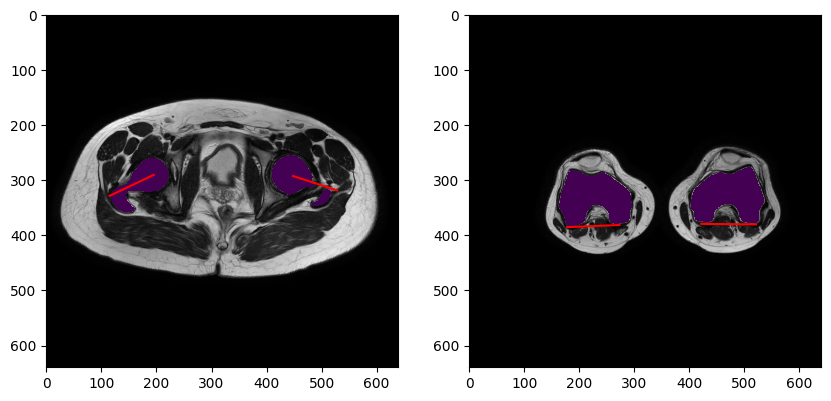

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 20))
ax[0].imshow(torsion_exam.hip.array[:, :, hip_layer].T, cmap='gray')
ax[0].imshow(np.where(torsion_exam.hip_mask.array[:, :, hip_layer] == 0, np.nan, torsion_exam.hip_mask.array[:, :, hip_layer]).T)
#ax[0].plot([torsion_exam.landmarks['femur']['right']['hip_start'][0], torsion_exam.landmarks['femur']['right']['hip_end'][0]], [torsion_exam.landmarks['femur']['right']['hip_start'][1], torsion_exam.landmarks['femur']['right']['hip_end'][1]], 'r')
#ax[0].plot([torsion_exam.landmarks['femur']['left']['hip_start'][0], torsion_exam.landmarks['femur']['left']['hip_end'][0]], [torsion_exam.landmarks['femur']['left']['hip_start'][1], torsion_exam.landmarks['femur']['left']['hip_end'][1]], 'r')
ax[1].imshow(torsion_exam.knee.array[:, :, knee_layer].T, cmap='gray')
ax[1].imshow(np.where(torsion_exam.knee_mask.array[:, :, knee_layer] == 0, np.nan, torsion_exam.knee_mask.array[:, :, knee_layer]).T)
#ax[1].plot([torsion_exam.landmarks['femur']['right']['knee_start'][0], torsion_exam.landmarks['femur']['right']['knee_end'][0]], [torsion_exam.landmarks['femur']['right']['knee_start'][1], torsion_exam.landmarks['femur']['right']['knee_end'][1]], 'r')
#ax[1].plot([torsion_exam.landmarks['femur']['left']['knee_start'][0], torsion_exam.landmarks['femur']['left']['knee_end'][0]], [torsion_exam.landmarks['femur']['left']['knee_start'][1], torsion_exam.landmarks['femur']['left']['knee_end'][1]], 'r')
plt.show()

In [36]:
ankle_layer = int(torsion_exam.landmarks['tibia']['left']['ankle_start'][-1])
knee_layer = int(torsion_exam.landmarks['tibia']['left']['knee_start'][-1])

In [37]:
np.unique(torsion_exam.ankle_mask.array[:, :, ankle_layer])

array([0., 1., 2.])

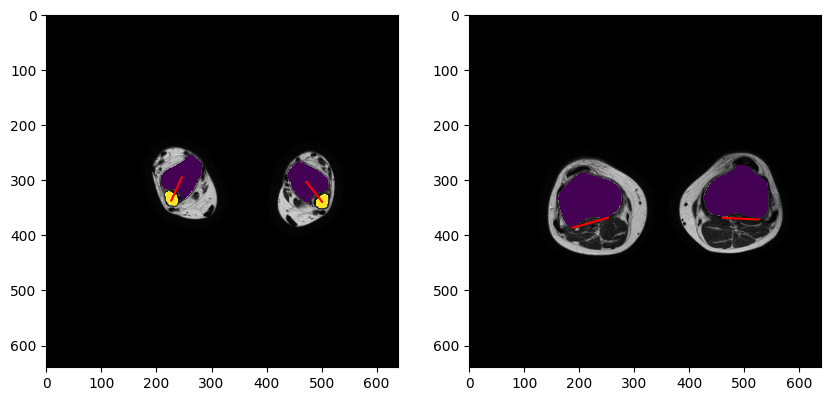

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 20))
ax[0].imshow(torsion_exam.ankle.array[:, :, ankle_layer].T, cmap='gray')
ax[0].imshow(np.where(torsion_exam.ankle_mask.array[:, :, ankle_layer] == 0, np.nan, torsion_exam.ankle_mask.array[:, :, ankle_layer]).T)
ax[0].plot([torsion_exam.landmarks['tibia']['right']['ankle_start'][0], torsion_exam.landmarks['tibia']['right']['ankle_end'][0]], [torsion_exam.landmarks['tibia']['right']['ankle_start'][1], torsion_exam.landmarks['tibia']['right']['ankle_end'][1]], 'r')
ax[0].plot([torsion_exam.landmarks['tibia']['left']['ankle_start'][0], torsion_exam.landmarks['tibia']['left']['ankle_end'][0]], [torsion_exam.landmarks['tibia']['left']['ankle_start'][1], torsion_exam.landmarks['tibia']['left']['ankle_end'][1]], 'r')
ax[1].imshow(torsion_exam.knee.array[:, :, knee_layer].T, cmap='grey')
ax[1].imshow(np.where(torsion_exam.knee_mask.array[:, :, knee_layer] == 0, np.nan, torsion_exam.knee_mask.array[:, :, knee_layer]).T)
ax[1].plot([torsion_exam.landmarks['tibia']['right']['knee_start'][0], torsion_exam.landmarks['tibia']['right']['knee_end'][0]], [torsion_exam.landmarks['tibia']['right']['knee_start'][1], torsion_exam.landmarks['tibia']['right']['knee_end'][1]], 'r')
ax[1].plot([torsion_exam.landmarks['tibia']['left']['knee_start'][0], torsion_exam.landmarks['tibia']['left']['knee_end'][0]], [torsion_exam.landmarks['tibia']['left']['knee_start'][1], torsion_exam.landmarks['tibia']['left']['knee_end'][1]], 'r')
plt.show()

In [41]:
torsion_exam.get_torsion_values()

{'femoral_torsion_left': 17.42543604030541,
 'femoral_torsion_right': 22.996688362337355,
 'tibial_torsion_left': 49.17271725621521,
 'tibial_torsion_right': 50.09834582809147}

In [10]:
tmp = torsion_exam.ankle_mask.array
tmp = np.where(tmp == 2, 3, tmp)
tmp = np.where(tmp == 1, 2, tmp)
segmented_array = np.concatenate((torsion_exam.hip_mask.array, torsion_exam.knee_mask.array, tmp), axis=2)

In [7]:
array = torsion_exam.transformed_image.array

In [8]:
torsion_exam.landmarks

defaultdict(dict,
            {'femur': {'right': {'hip_start': [195, 290, 14],
               'hip_end': [115, 328, 14],
               'knee_start': [273, 381, 18],
               'knee_end': [178, 385, 18]},
              'left': {'hip_start': [448, 292, 15],
               'hip_end': [528, 318, 15],
               'knee_start': [521, 380, 19],
               'knee_end': [422, 379, 19]}},
             'tibia': {'right': {'knee_start': [252, 368, 28],
               'knee_end': [188, 386, 28],
               'ankle_start': [245.8434065934066, 294.538961038961, 14.0],
               'ankle_end': [226.9497487437186, 336.5929648241206, 14.0]},
              'left': {'knee_start': [526, 371, 28],
               'knee_end': [461, 368, 28],
               'ankle_start': [472.6115594897162, 302.91642801353817, 15.0],
               'ankle_end': [500.9068965517241, 338.89310344827584, 15.0]}}})

In [11]:
np.unique(segmented_array)

array([0., 1., 2., 3.])

In [14]:
torsion_exam.hip.shape

(640, 640, 31)

In [12]:
from matplotlib.colors import ListedColormap, BoundaryNorm

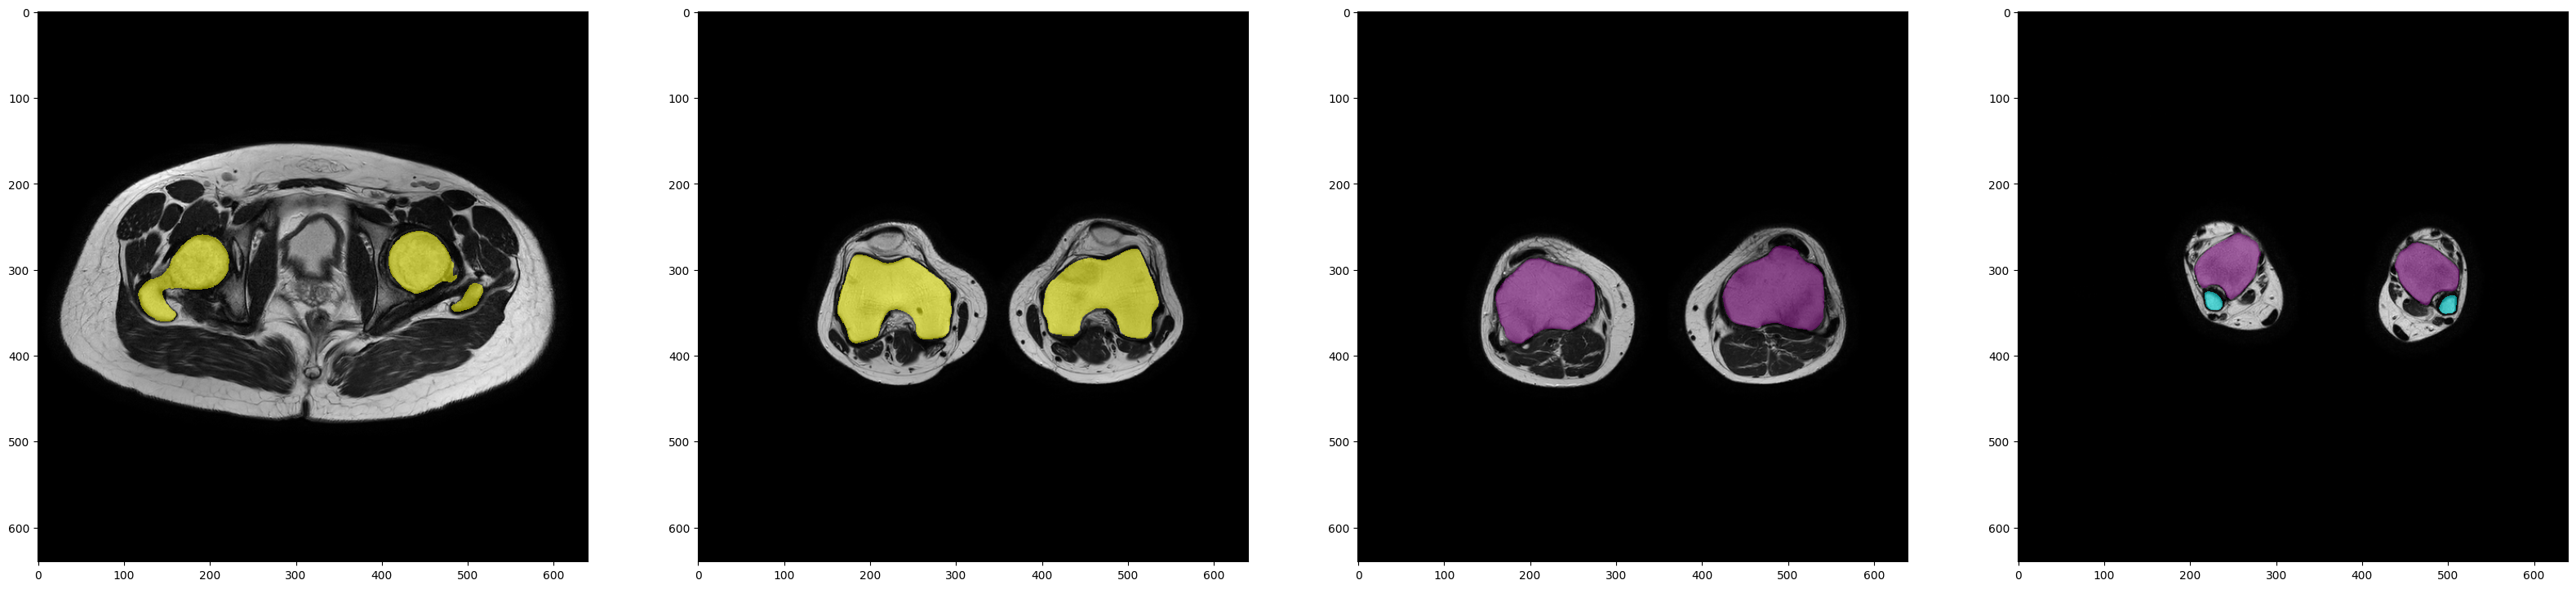

In [20]:
fig, ax = plt.subplots(ncols=4, figsize=(40, 10))

colours = ['white', 'yellow', 'purple', 'cyan']
cmap = ListedColormap(colours)

bounds = [-1, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

segmented_array = np.where(segmented_array == 0, np.nan, segmented_array)

ax[0].imshow(array[:, :, 14].T, cmap='gray')
ax[0].imshow(segmented_array[:, :, 14].T, cmap=cmap, norm=norm, alpha=0.5)

ax[1].imshow(array[:, :, torsion_exam.hip.shape[-1] + 18].T, cmap='gray')
ax[1].imshow(segmented_array[:, :, torsion_exam.hip.shape[-1] + 18].T, cmap=cmap, norm=norm, alpha=0.5)

ax[2].imshow(array[:, :, torsion_exam.hip.shape[-1] + 28].T, cmap='gray')
ax[2].imshow(segmented_array[:, :, torsion_exam.hip.shape[-1] + 28].T, cmap=cmap, norm=norm, alpha=0.5)

ax[3].imshow(array[:, :, torsion_exam.hip.shape[-1] + torsion_exam.knee.shape[-1] + 14].T, cmap='gray')
ax[3].imshow(segmented_array[:, :, torsion_exam.hip.shape[-1] + torsion_exam.knee.shape[-1] + 14].T, cmap=cmap, norm=norm, alpha=0.5)

plt.show()